# Model Explainability

This notebook explains the behaviour of the trained fraud detection models.

The main objective is to identify which features contributed most to fraud prediction and to provide business interpretation of the model outputs.

In [1]:
# Import libraries

import pandas as pd
import joblib
import matplotlib.pyplot as plt

Loading saved models

In [2]:
# Loading saved models

rf = joblib.load("../models/random_forest_model.pkl")
xgb = joblib.load("../models/xgboost_model.pkl")

Loading training features

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")

X_train.head()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,...,ip_country_us,kyc_tier_low,kyc_tier_standard,kyc_tier_unknown,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,278.19,278.19,4.25,1.351351,0,0,0.123,263,0.522,0,...,1,0,1,0,1,0,0,0,0,0
1,208.51,154.29,4.24,12.758621,1,0,0.569,947,0.475,0,...,0,0,1,0,1,0,0,0,0,0
2,160.33,160.33,2.70,7.142857,0,0,0.437,367,0.939,0,...,1,0,0,0,1,0,0,0,0,0
3,59.41,59.41,2.22,0.925926,0,0,0.594,147,0.551,0,...,1,0,1,0,0,0,0,0,1,0
4,200.96,200.96,3.61,83.333333,0,0,0.121,257,0.894,0,...,1,0,0,0,0,0,0,0,1,0


Random Forest feature importance

In [4]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
6,ip_risk_score,0.119990
11,txn_velocity_1h,0.115739
12,txn_velocity_24h,0.112517
7,account_age_days,0.092158
10,risk_score_internal,0.077077
8,device_trust_score,0.060366
0,amount_src,0.055369
2,fee,0.048303
1,amount_usd,0.046380
17,amount_dest,0.036596


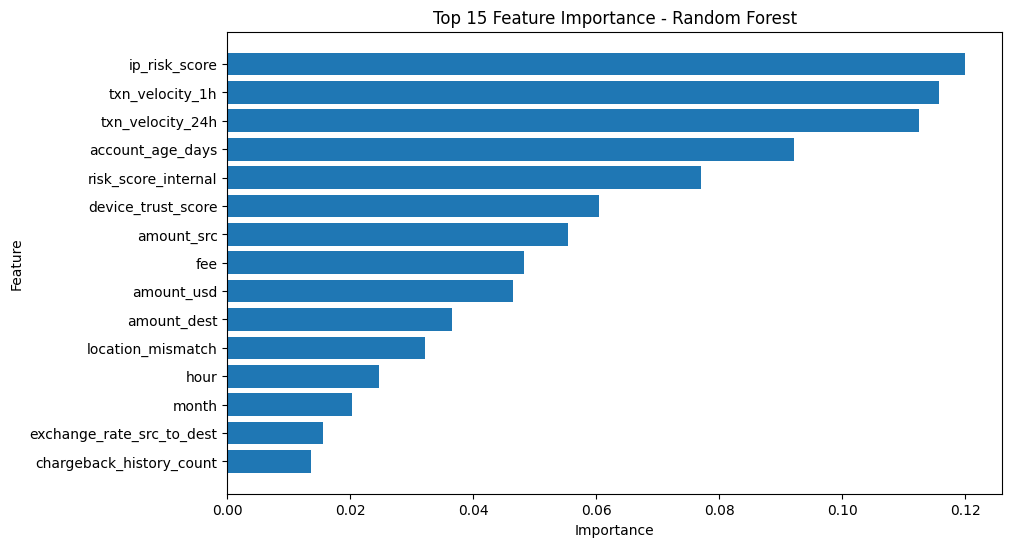

In [5]:
top_rf = rf_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Random Forest")

plt.gca().invert_yaxis()
plt.show()

 XGBoost feature importance

In [ ]:
# XGBoost feature importance

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(15)

,Feature,Importance
11,txn_velocity_1h,0.380957
12,txn_velocity_24h,0.298644
7,account_age_days,0.025365
39,kyc_tier_unknown,0.016806
23,dest_currency_cny,0.014147
25,dest_currency_gbp,0.012049
27,dest_currency_mxn,0.011344
6,ip_risk_score,0.011279
37,kyc_tier_low,0.011053
4,new_device,0.010367


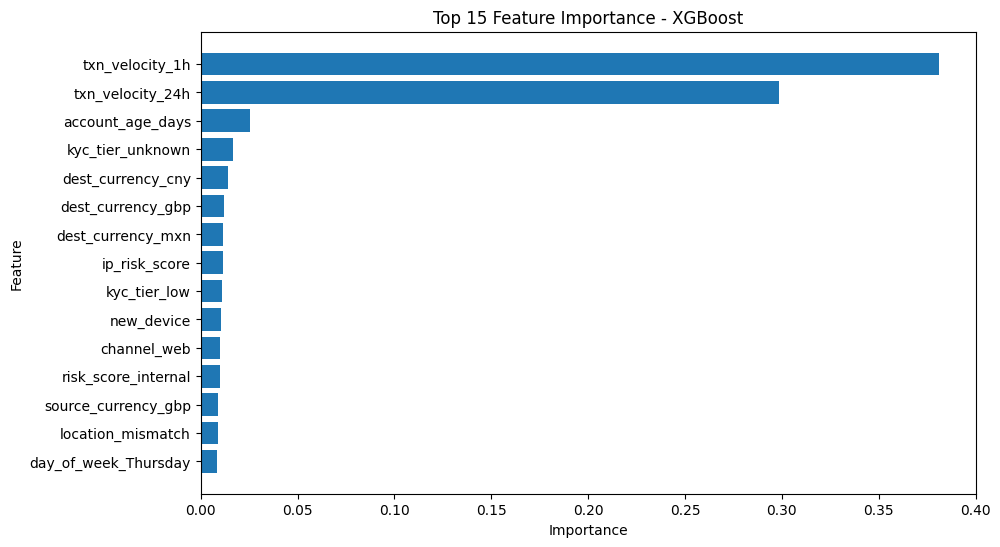

In [7]:
top_xgb = xgb_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xgb["Feature"],
    top_xgb["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - XGBoost")

plt.gca().invert_yaxis()
plt.show()

## Business Interpretation

The feature importance analysis shows which variables contributed most to fraud prediction.

Features such as transaction velocity, IP risk score, device trust score, chargeback history, new device usage, and internal risk scores are expected to be strong fraud indicators.

This suggests that fraud is driven more by behavioural and risk-based patterns than by transaction amount alone.

## Explainability Summary

Random Forest and XGBoost feature importance were used to understand the main drivers of fraud prediction.

XGBoost was selected as the final model because it achieved the best fraud detection performance, with the highest recall and F1-score for the fraud class.

The explainability analysis supports the model results by showing that the most important features align with realistic fraud indicators, including risky IP behaviour, high transaction velocity, new device usage, weak device trust, and previous chargeback activity.